# Notebook 04: Evaluation on CIFAR-10 and CIFAR-10-C

This notebook evaluates trained checkpoints on clean CIFAR-10 and CIFAR-10-C. CIFAR-10-C must be downloaded separately and extracted as `data/CIFAR-10-C/*.npy`.

Outputs:

- Per-corruption and per-severity accuracy/error CSV files.
- Heatmaps for corruption trends.
- A model comparison chart for clean and corrupted accuracy.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import torch
import matplotlib.pyplot as plt

from robust_cifar.data import make_cifar10_loaders, CIFAR10_CLASSES
from robust_cifar.models import build_resnet18_cifar, count_parameters
from robust_cifar.train import get_device, seed_everything

seed_everything(42)
device = get_device()
device

device(type='cuda')

## Load Checkpoints

Run the training notebooks first, or change these paths to your checkpoint locations.

In [2]:
from robust_cifar.models import load_checkpoint

checkpoint_paths = {
    "Baseline": PROJECT_ROOT / "checkpoints" / "resnet18_baseline.pt",
    "AugMix": PROJECT_ROOT / "checkpoints" / "resnet18_augmix.pt",
    "Proposed": PROJECT_ROOT / "checkpoints" / "resnet18_consistency.pt",
}

models = {}
for name, path in checkpoint_paths.items():
    model = build_resnet18_cifar()
    if path.exists():
        load_checkpoint(model, path, device=device)
        models[name] = model.to(device)
    else:
        print(f"Missing checkpoint for {name}: {path}")
models.keys()

D:\DeepLearning\Codex\2026-04-27\project-title-improving-robustness-of-deep\src\robust_cifar\models.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(p

dict_keys(['Baseline', 'AugMix', 'Proposed'])

## Evaluate Clean Accuracy

In [3]:
_, test_loader = make_cifar10_loaders(
    data_dir=PROJECT_ROOT / "data",
    batch_size=64,
    num_workers=2,
    mode="baseline",
    download=True,
)

from robust_cifar.train import evaluate_clean

clean_rows = []
for name, model in models.items():
    metrics = evaluate_clean(model, test_loader, device)
    clean_rows.append({"model": name, "clean_accuracy": metrics["accuracy"], "clean_error": 1 - metrics["accuracy"]})
clean_df = pd.DataFrame(clean_rows)
clean_df

Files already downloaded and verified
Files already downloaded and verified


,model,clean_accuracy,clean_error
0,Baseline,0.9449,0.0551
1,AugMix,0.9532,0.0468
2,Proposed,0.9385,0.0615


## Evaluate CIFAR-10-C

This cell can take time because it evaluates 15 corruptions x 5 severity levels for each model.

In [4]:
from robust_cifar.evaluate import evaluate_cifar10c, summarize_corruption_results, save_cifar10c_results

cifar10c_dir = PROJECT_ROOT / "data" / "CIFAR-10-C"
cifar10c_results = {}
summary_rows = []

baseline_df = None
for name, model in models.items():
    df = evaluate_cifar10c(model, cifar10c_dir, batch_size=64, num_workers=2, device=device)
    summary = summarize_corruption_results(df, baseline_df=baseline_df)
    if name == "Baseline":
        baseline_df = df
        summary = summarize_corruption_results(df)
    clean_row = clean_df.loc[clean_df["model"] == name].iloc[0].to_dict()
    summary_rows.append({"model": name, **clean_row, **summary})
    cifar10c_results[name] = df
    save_cifar10c_results(df, PROJECT_ROOT / "reports" / f"{name.lower()}_cifar10c.csv", summary)

summary_df = pd.DataFrame(summary_rows)
summary_df

,model,clean_accuracy,clean_error,mean_corrupted_accuracy,mean_corruption_error,relative_mce
0,Baseline,0.9449,0.0551,0.730780,0.269220,NaN
1,AugMix,0.9532,0.0468,0.860787,0.139213,0.517099
2,Proposed,0.9385,0.0615,0.889424,0.110576,0.410727


## Corruption Heatmaps and Model Comparison

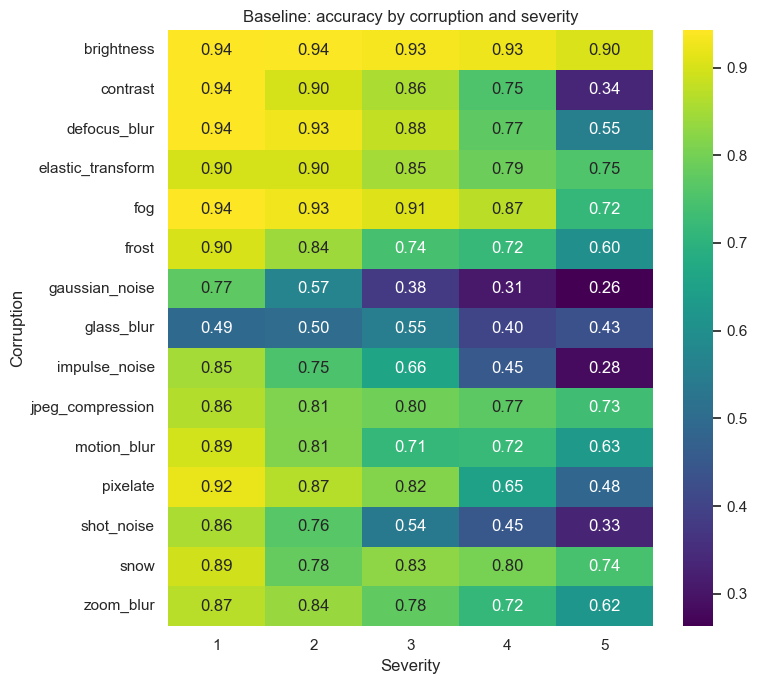

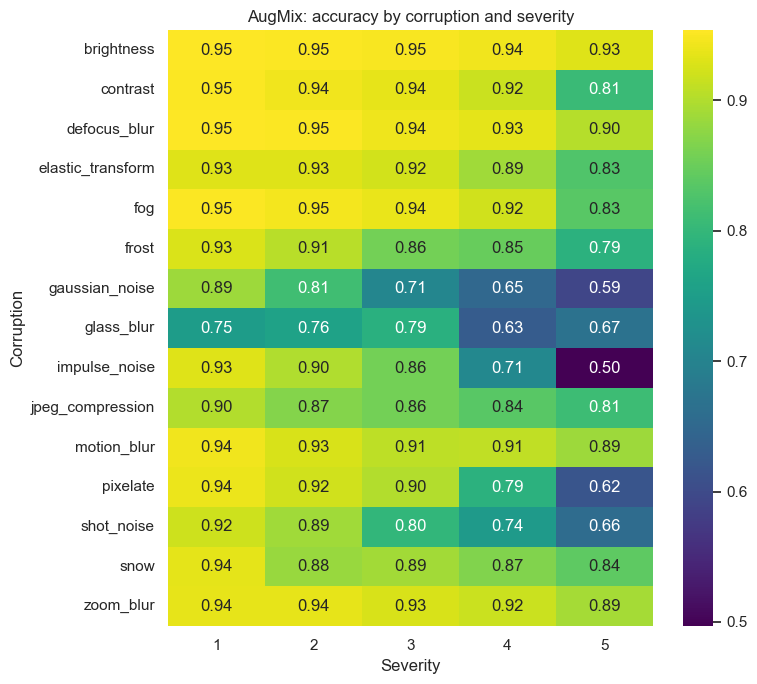

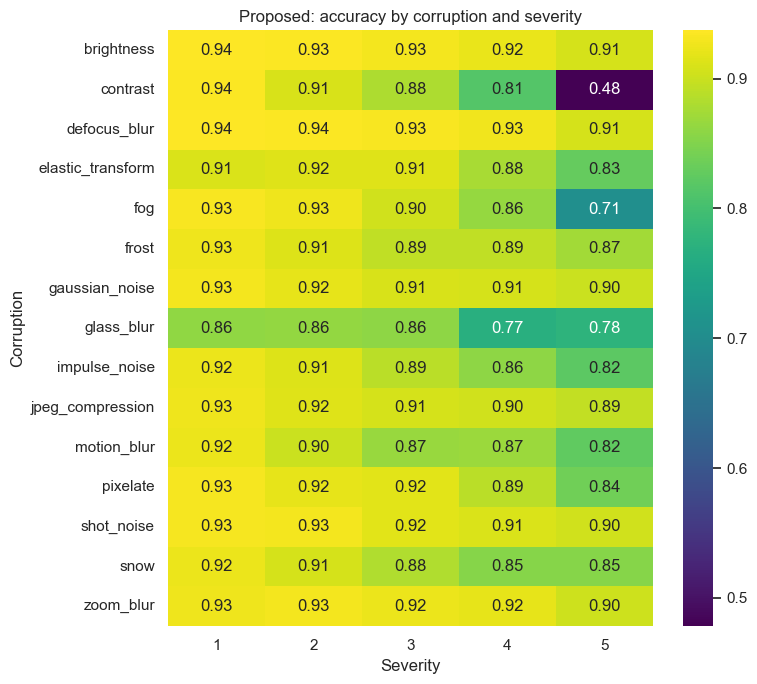

D:\DeepLearning\Codex\2026-04-27\project-title-improving-robustness-of-deep\src\robust_cifar\visualize.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(summary, x="model", y="clean_accuracy", ax=axes[0], palette="Set2")
D:\DeepLearning\Codex\2026-04-27\project-title-improving-robustness-of-deep\src\robust_cifar\visualize.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(summary, x="model", y="mean_corrupted_accuracy", ax=axes[1], palette="Set2")


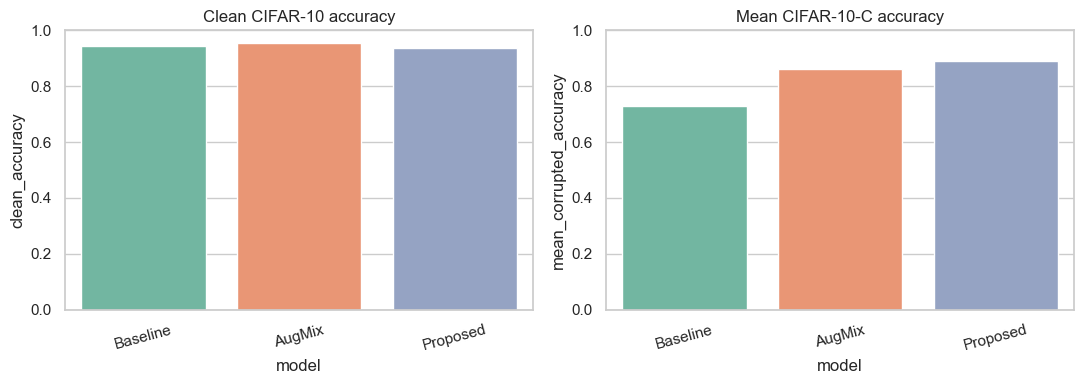

In [5]:
from robust_cifar.visualize import plot_corruption_heatmap, plot_model_comparison

for name, df in cifar10c_results.items():
    plot_corruption_heatmap(
        df,
        metric="accuracy",
        title=name,
        output_path=PROJECT_ROOT / "reports" / "figures" / f"{name.lower()}_cifar10c_heatmap.png",
    )
    plt.show()

plot_model_comparison(
    summary_df,
    output_path=PROJECT_ROOT / "reports" / "figures" / "model_comparison.png",
)
plt.show()

## Expected Interpretation

The baseline should usually keep high clean accuracy but drop sharply on noise and blur corruptions. AugMix should improve mean corrupted accuracy. The proposed consistency method should improve corrupted accuracy while preserving clean accuracy, especially on corruptions similar to the controlled training corruptions.